In [ ]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import MeanShift
from sklearn.cluster import SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import LabelEncoder
from sklearn.mixture import GaussianMixture
from sklearn.impute import SimpleImputer
from sklearn.manifold import TSNE

In [5]:

df = pd.read_csv("CC GENERAL.csv")
df.head()


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [6]:
df.tail()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
8945,C19186,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.50,6
8946,C19187,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,NaN,0.00,6
8947,C19188,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.25,6
8948,C19189,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.25,6
8949,C19190,372.708075,0.666667,1093.25,1093.25,0.00,127.040008,0.666667,0.666667,0.000000,0.333333,2,23,1200.0,63.165404,88.288956,0.00,6


In [7]:
print(df.columns)
print(df.dtypes)


Index(['CUST_ID', 'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES',
       'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE',
       'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY',
       'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY',
       'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS',
       'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE'],
      dtype='object')
CUST_ID                              object
BALANCE                             float64
BALANCE_FREQUENCY                   float64
PURCHASES                           float64
ONEOFF_PURCHASES                    float64
INSTALLMENTS_PURCHASES              float64
CASH_ADVANCE                        float64
PURCHASES_FREQUENCY                 float64
ONEOFF_PURCHASES_FREQUENCY          float64
PURCHASES_INSTALLMENTS_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY              float64
CASH_ADVANCE_TRX                      int64
PURCHASES_TRX                         int64
CREDIT_LIMIT   

In [8]:
print(df.isnull().sum())
print('Nombre de doublons :', df.duplicated().sum())


CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64
Nombre de doublons : 0


In [9]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(num_cols)
print(cat_cols)

['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']
['CUST_ID']


In [10]:
display(df.describe(include='all'))
display(df[num_cols].var(numeric_only=True))

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
unique,8950,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,C10001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,NaN,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,NaN,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,NaN,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,NaN,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000


BALANCE                             4.332775e+06
BALANCE_FREQUENCY                   5.612351e-02
PURCHASES                           4.565208e+06
ONEOFF_PURCHASES                    2.755228e+06
INSTALLMENTS_PURCHASES              8.178274e+05
CASH_ADVANCE                        4.398096e+06
PURCHASES_FREQUENCY                 1.610985e-01
ONEOFF_PURCHASES_FREQUENCY          8.900441e-02
PURCHASES_INSTALLMENTS_FREQUENCY    1.579647e-01
CASH_ADVANCE_FREQUENCY              4.004857e-02
CASH_ADVANCE_TRX                    4.657580e+01
PURCHASES_TRX                       6.179027e+02
CREDIT_LIMIT                        1.324098e+07
PAYMENTS                            8.381394e+06
MINIMUM_PAYMENTS                    5.628503e+06
PRC_FULL_PAYMENT                    8.555578e-02
TENURE                              1.791129e+00
dtype: float64

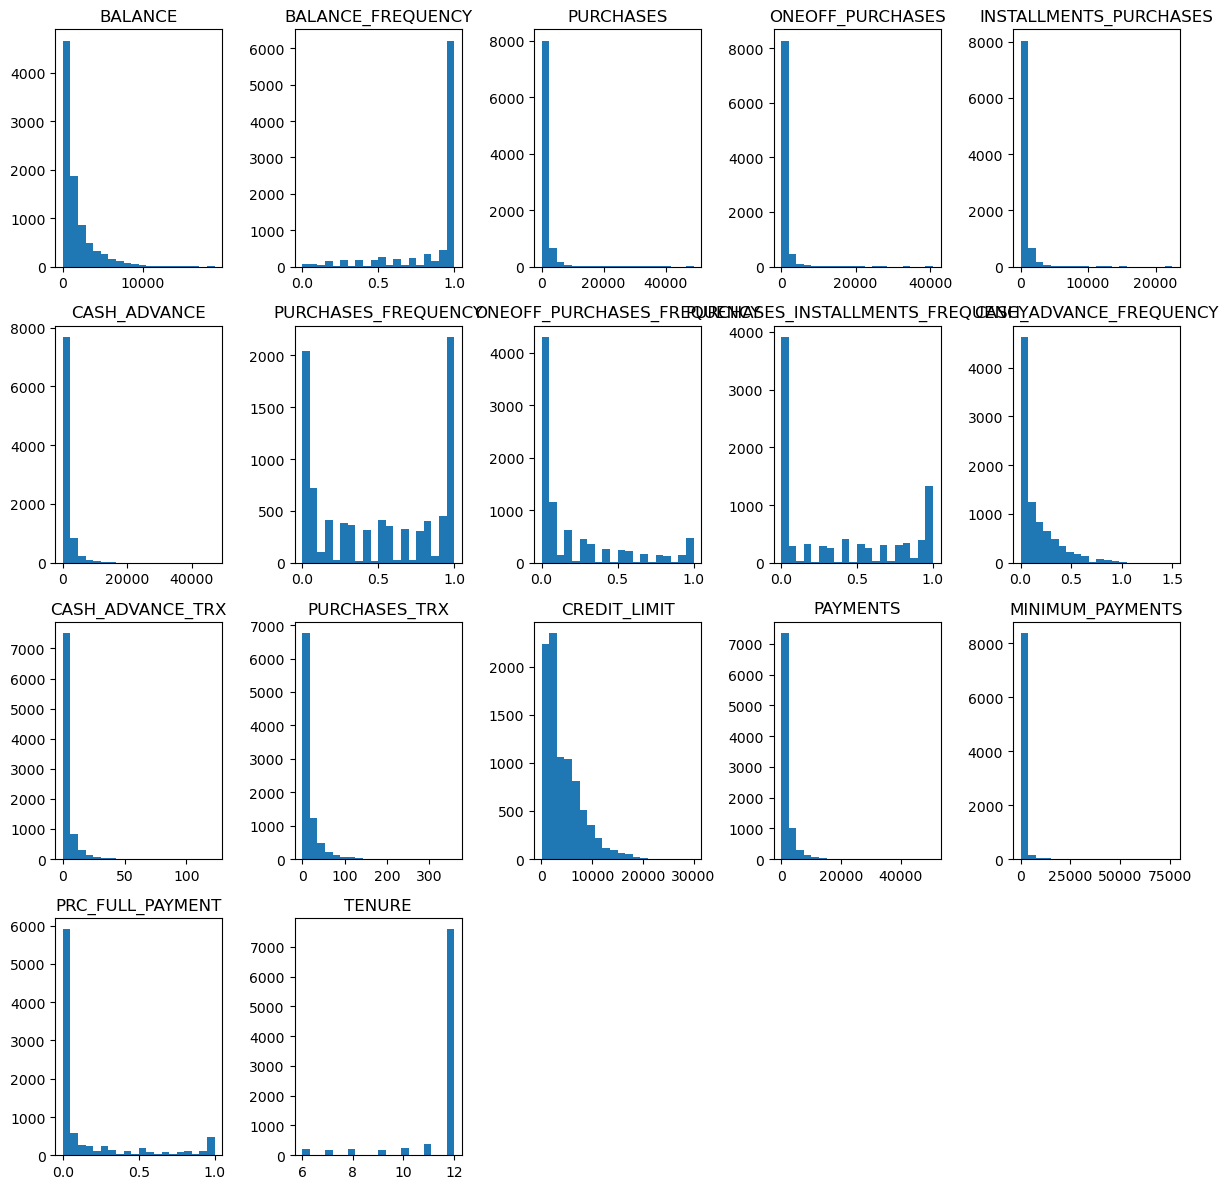

In [11]:
n = len(num_cols)

# nombre de colonnes et lignes carrées
cols = math.ceil(math.sqrt(n))
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(12,12))

axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=20)
    axes[i].set_title(col)

# supprimer les cases vides
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.savefig("histograme.png", dpi=300)

plt.tight_layout()
plt.show()


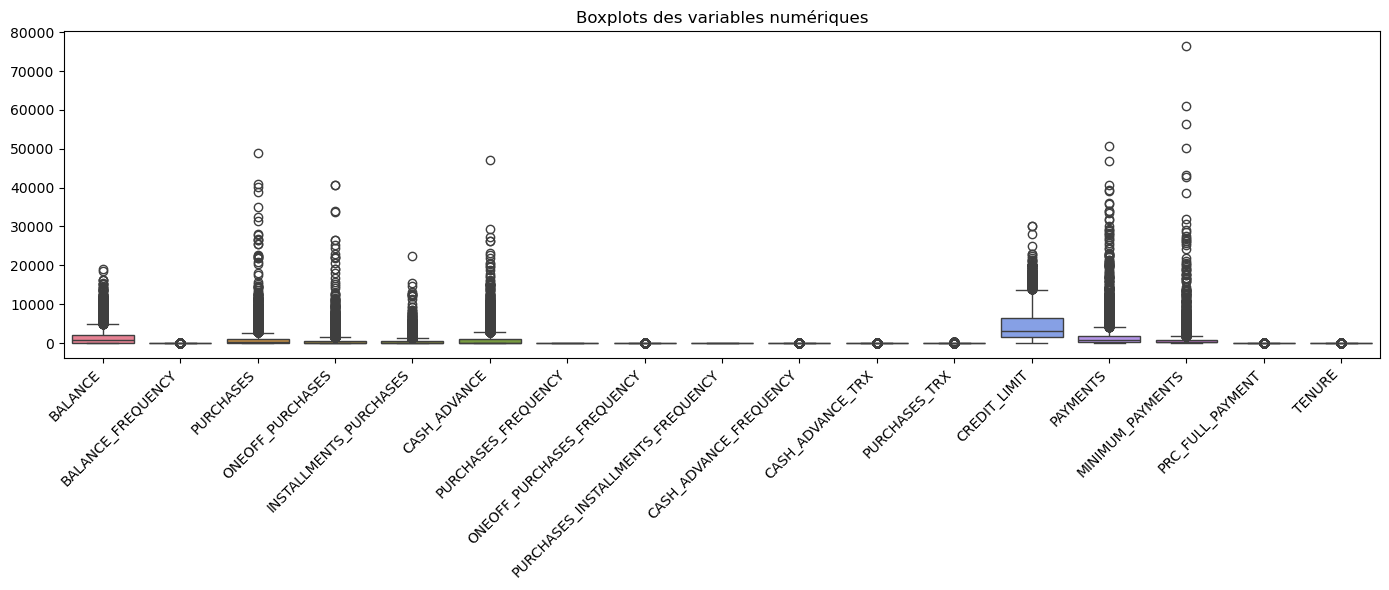

In [12]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=df[num_cols])
plt.title('Boxplots des variables numériques')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("bxplots.png", dpi=300)

plt.show()


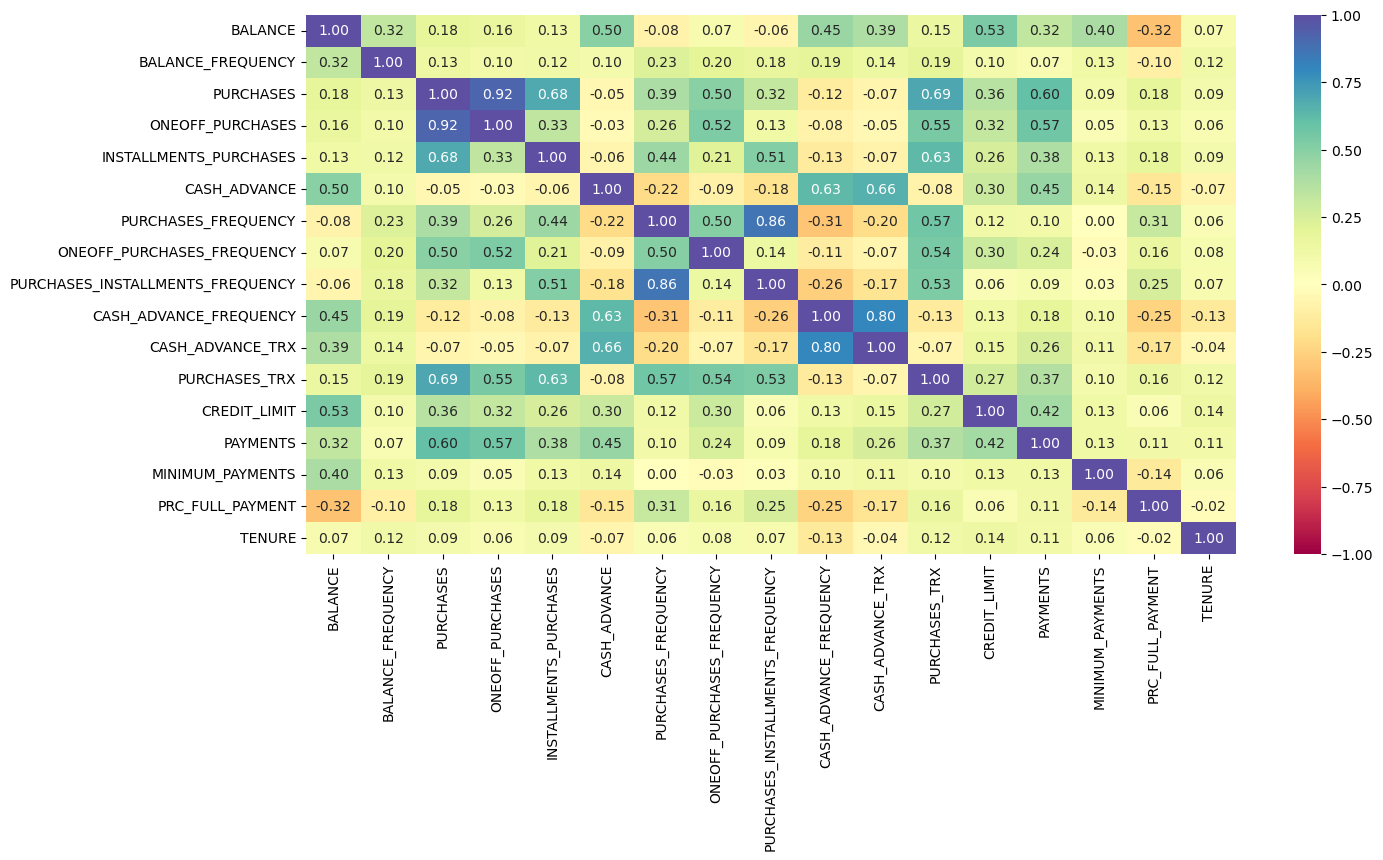

In [13]:
# Correlation check
cols_list = df.select_dtypes(include = np.number).columns.tolist()

plt.figure(figsize = (15, 7))

sns.heatmap(
    df[cols_list].corr(numeric_only = True), annot = True, vmin = -1, vmax = 1, fmt = ".2f", cmap = "Spectral"
)
plt.savefig("matrice de coreelation.png", dpi=300)

plt.show()

In [14]:
work_df = df.copy()
num_cols = work_df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = work_df.select_dtypes(include=['object']).columns
print("Colonnes numériques :", num_cols)
print("Colonnes catégorielles :", cat_cols)

Colonnes numériques : Index(['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES',
       'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY',
       'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY',
       'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX',
       'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT',
       'TENURE'],
      dtype='object')
Colonnes catégorielles : Index(['CUST_ID'], dtype='object')


In [15]:
le = LabelEncoder()
for col in cat_cols:
    work_df[col] = le.fit_transform(work_df[col].astype(str))
print("Après Label Encoding :")
print(work_df.head())


Après Label Encoding :
   CUST_ID      BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
0        0    40.900749           0.818182      95.40              0.00   
1        1  3202.467416           0.909091       0.00              0.00   
2        2  2495.148862           1.000000     773.17            773.17   
3        3  1666.670542           0.636364    1499.00           1499.00   
4        4   817.714335           1.000000      16.00             16.00   

   INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
0                    95.4      0.000000             0.166667   
1                     0.0   6442.945483             0.000000   
2                     0.0      0.000000             1.000000   
3                     0.0    205.788017             0.083333   
4                     0.0      0.000000             0.083333   

   ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
0                    0.000000                          0.083333   
1      

In [16]:
scaler = StandardScaler()
work_df[num_cols] = scaler.fit_transform(work_df[num_cols])
print("Après StandardScaler :")
print(work_df.head())

Après StandardScaler :
   CUST_ID   BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
0        0 -0.731989          -0.249434  -0.424900         -0.356934   
1        1  0.786961           0.134325  -0.469552         -0.356934   
2        2  0.447135           0.518084  -0.107668          0.108889   
3        3  0.049099          -1.016953   0.232058          0.546189   
4        4 -0.358775           0.518084  -0.462063         -0.347294   

   INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
0               -0.349079     -0.466786            -0.806490   
1               -0.454576      2.605605            -1.221758   
2               -0.454576     -0.466786             1.269843   
3               -0.454576     -0.368653            -1.014125   
4               -0.454576     -0.466786            -1.014125   

   ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
0                   -0.678661                         -0.707313   
1                   -0.67

In [17]:
work_df_clean = work_df.dropna()


In [18]:
# Colonnes numérique
num_cols = work_df.select_dtypes(include=['int64', 'float64']).columns

# Isolation Forest capable de Détecte et Supprimer les outliers
iso = IsolationForest(
    contamination=0.05,
    random_state=42
)
outliers = iso.fit_predict(work_df[num_cols])
print(outliers)
work_df_clean = work_df[outliers == 1]

[ 1  1  1 ...  1  1 -1]


[[-1.08006561 -1.46573361]
 [-2.45999849  2.75783446]
 [ 1.40832137  0.93167876]
 [-0.33406947  0.31398419]
 [-1.20504371 -0.96703687]]
Variance expliquée par PC1 et PC2 :
[0.26911334 0.18162833]


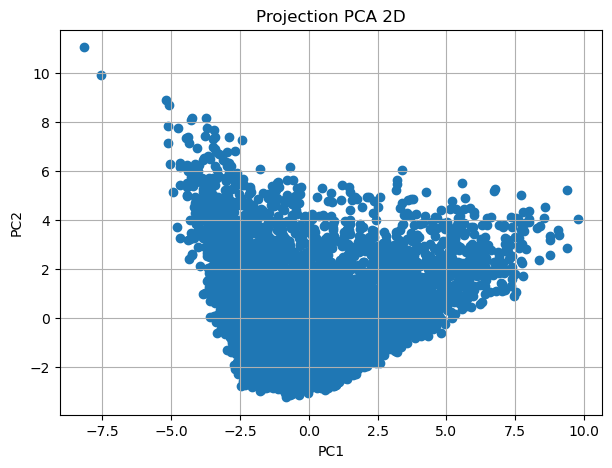

In [ ]:

X = work_df_clean.select_dtypes(include=['int64', 'float64'])
scaler = StandardScaler()
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)
X_scaled = scaler.fit_transform(X)
# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(X_pca[:5])


print("Variance expliquée par PC1 et PC2 :")
print(pca.explained_variance_ratio_)
plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1])
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Projection PCA 2D')
plt.savefig("projection pca.png", dpi=300)

plt.grid(True)
plt.show()

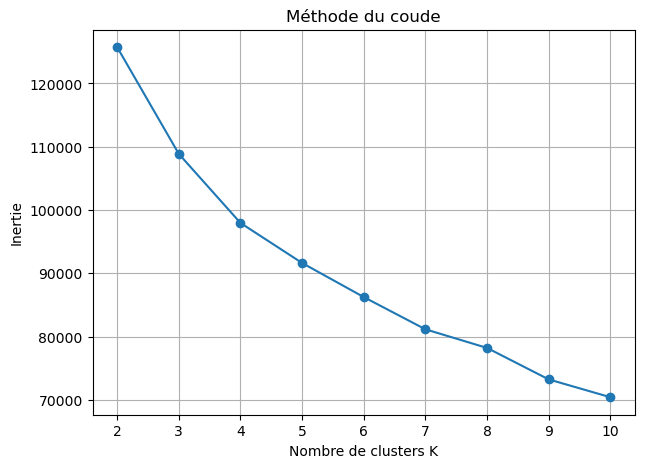

In [ ]:

inertias = []
K_range = range(2, 11)

for k in K_range:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)
    inertias.append(model.inertia_)

plt.figure(figsize=(7,5))

plt.plot(K_range, inertias, marker='o')

plt.xlabel('Nombre de clusters K')
plt.ylabel('Inertie')
plt.title('Méthode du coude')
plt.savefig("methode de coude.png", dpi=300)

plt.grid(True)
plt.show()

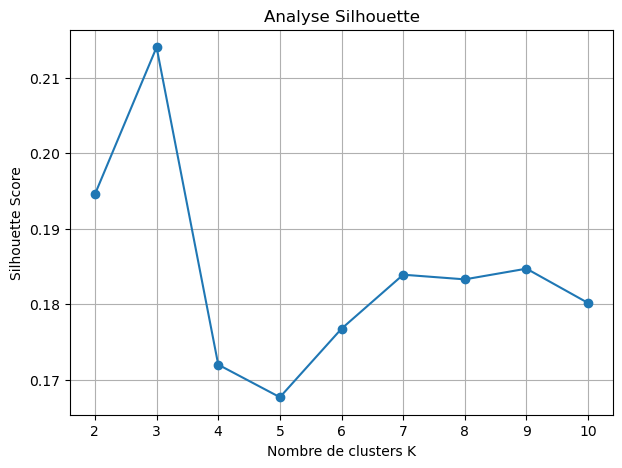

Meilleur K selon silhouette : 3


In [ ]:
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    silhouette_scores.append(score)

plt.figure(figsize=(7,5))

plt.plot(K_range, silhouette_scores, marker='o')

plt.xlabel('Nombre de clusters K')
plt.ylabel('Silhouette Score')
plt.title('Analyse Silhouette')
plt.savefig("silhoute.png", dpi=300)

plt.grid(True)
plt.show()

best_k = list(K_range)[np.argmax(silhouette_scores)]

print("Meilleur K selon silhouette :", best_k)

In [ ]:
X = work_df.select_dtypes(include=['int64', 'float64'])


imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)


models = {

    'KMeans': KMeans(
        n_clusters=best_k,
        random_state=42,
        n_init=10
    ),

    'DBSCAN': DBSCAN(
        eps=1.5,
        min_samples=5
    ),

    'Agglomerative': AgglomerativeClustering(
        n_clusters=best_k
    ),

    'MeanShift': MeanShift(),

    'GMM': GaussianMixture(
        n_components=best_k,
        random_state=42
    ),

    'Spectral': SpectralClustering(
        n_clusters=best_k,
        random_state=42,
        affinity='nearest_neighbors'
    )
}



cluster_results = {}

for name, model in models.items():

    print("Entraînement :", name)

    # Cas spécial GMM
    if name == 'GMM':
        labels = model.fit_predict(X_scaled)

    else:
        labels = model.fit_predict(X_scaled)

    cluster_results[name] = labels

    print("Clusters trouvés :", set(labels))
    print("-" * 40)

Entraînement : KMeans
Clusters trouvés : {np.int32(0), np.int32(1), np.int32(2)}
----------------------------------------
Entraînement : DBSCAN
Clusters trouvés : {np.int64(0), np.int64(1), np.int64(2), np.int64(-1)}
----------------------------------------
Entraînement : Agglomerative
Clusters trouvés : {np.int64(0), np.int64(1), np.int64(2)}
----------------------------------------
Entraînement : MeanShift
Clusters trouvés : {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.i

In [ ]:
def evaluate_clustering(X, labels):

   
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    # Cas invalide
    if n_clusters < 2:
        return {
            'Nombre clusters': n_clusters,
            'Silhouette': np.nan,
            'Davies-Bouldin': np.nan,
            'Calinski-Harabasz': np.nan
        }

    return {
        'Nombre clusters': n_clusters,

        'Silhouette':
            silhouette_score(X, labels),

        'Davies-Bouldin':
            davies_bouldin_score(X, labels),

        'Calinski-Harabasz':
            calinski_harabasz_score(X, labels)
    }

results = []

for name, labels in cluster_results.items():

    metrics = evaluate_clustering(X_scaled, labels)

    metrics['Modèle'] = name

    results.append(metrics)


results_df = pd.DataFrame(results)

results_df = results_df[
    [
        'Modèle',
        'Nombre clusters',
        'Silhouette',
        'Davies-Bouldin',
        'Calinski-Harabasz'
    ]
]
results_df = results_df.sort_values(
    by='Silhouette',
    ascending=False
)

print(results_df)

          Modèle  Nombre clusters  Silhouette  Davies-Bouldin  \
3      MeanShift               73    0.279734        0.891982   
0         KMeans                3    0.230071        1.674813   
5       Spectral                3    0.146243        1.869208   
2  Agglomerative                3    0.121995        1.995419   
4            GMM                3    0.087884        3.142326   
1         DBSCAN                3    0.048108        2.034622   

   Calinski-Harabasz  
3          62.380644  
0        1504.789750  
5        1186.228559  
2        1140.966375  
4         765.277450  
1         317.916326  


In [ ]:



def plot_clusters(data_2d, labels, title="Clusters 2D"):
    plt.figure(figsize=(7, 5))

    unique_labels = np.unique(labels)

    for label in unique_labels:
       
        if label == -1:
            color = "black"
            label_name = "Bruit"



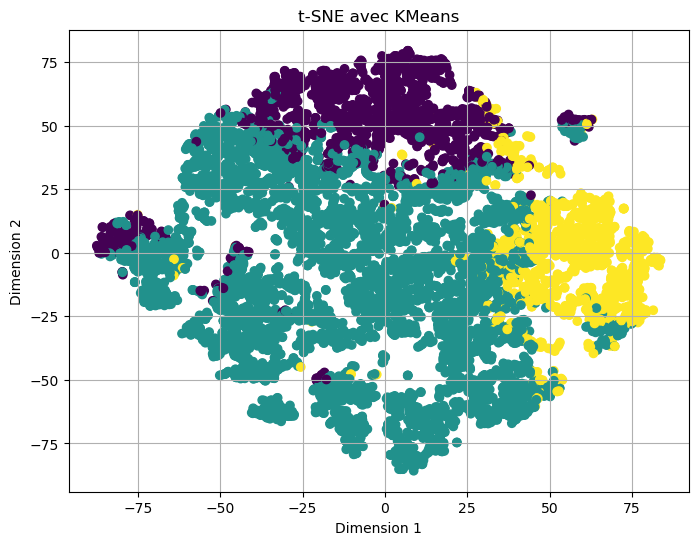

In [36]:

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

X_tsne = tsne.fit_transform(X_scaled)
def plot_clusters(X, labels, title):

    plt.figure(figsize=(8,6))

    plt.scatter(
        X[:,0],
        X[:,1],
        c=labels
    )

    plt.title(title)
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.savefig("tsnGHe.png", dpi=300)
    plt.grid(True)
    plt.show()

plot_clusters(
    X_tsne,
    cluster_results['KMeans'],
    't-SNE avec KMeans'
)


## 1. UMAP

In [26]:
pip install umap-learn

Note: you may need to restart the kernel to use updated packages.


c:\Users\dell\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


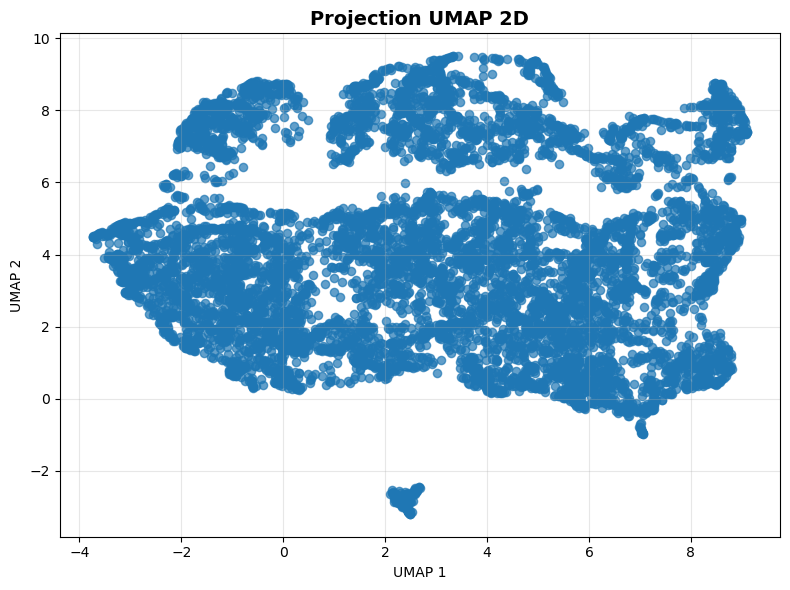

In [ ]:
import umap

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

X_umap = reducer.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_umap[:, 0], X_umap[:, 1], s=35, alpha=0.7)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("Projection UMAP 2D", fontsize=14, fontweight="bold")
plt.grid(alpha=0.3)
plt.savefig("Projection_UMAP_2D.png", dpi=300)
plt.tight_layout()
plt.show()

## 2. HDBSCAN

In [28]:
pip install hdbscan

Note: you may need to restart the kernel to use updated packages.


## 3. Analyse des centroïdes KMeans 

In [ ]:
kmeans_final = models['KMeans']

centroids = kmeans_final.cluster_centers_

centroids_df = pd.DataFrame(centroids)
centroids_df.head()


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,-0.187744,1.167512,0.347930,-0.289210,-0.206266,-0.304955,1.369227,-0.638448,-0.304755,-0.550894,1.543955,1.326650,-0.365345,0.604007,0.438913,0.401947,-0.412821,-0.104952
1,0.146888,-0.373646,-0.186327,-0.237986,-0.209512,-0.177696,-0.308997,-0.073048,-0.249244,-0.051771,-0.331250,-0.297078,-0.249431,-0.348586,-0.286477,-0.137524,0.006226,-0.036902
2,-0.454164,0.296596,0.439480,1.474354,1.237790,1.211634,-0.257188,1.136662,1.546417,0.928059,-0.370449,-0.260009,1.622701,0.880573,0.795213,0.143722,0.484633,0.303422


## 4. Importance des variables dans PCA

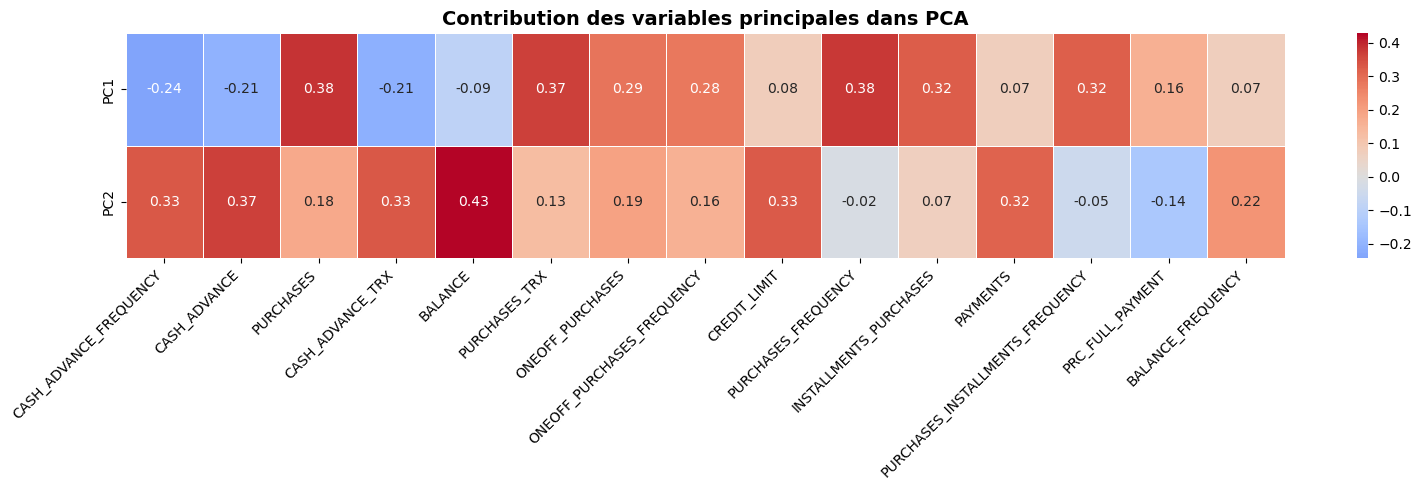

In [ ]:

feature_names = list(num_cols)

pca_importance = pd.DataFrame(
    pca.components_,
    columns=feature_names,
    index=["PC1", "PC2"]
)
top_pca_features = (
    pca_importance
    .abs()
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .index
)
plt.figure(figsize=(16, 5))

sns.heatmap(
    pca_importance[top_pca_features],
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title(
    "Contribution des variables principales dans PCA",
    fontsize=14,
    fontweight="bold"
)

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.savefig("Contribution_Variables_PCA.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()


## 5. Robustesse avec bruit 

Silhouette avec bruit : 0.21683483485004923


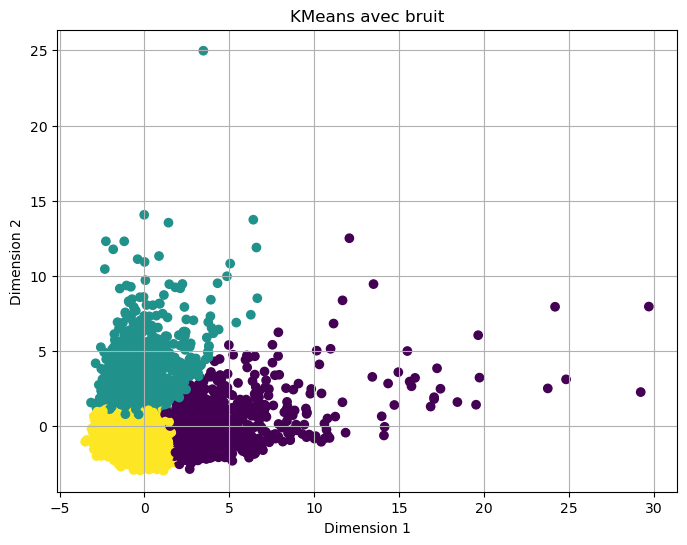

In [31]:
noise = np.random.normal(0, 0.2, X_scaled.shape)
X_noisy =X_scaled + noise

km_noise = KMeans(n_clusters=best_k, random_state=42, n_init=10)
noise_labels = km_noise.fit_predict(X_noisy)

print('Silhouette avec bruit :', silhouette_score(X_noisy, noise_labels))

X_noisy_pca = PCA(n_components=2, random_state=42).fit_transform(X_noisy)
plot_clusters(X_noisy_pca, noise_labels, 'KMeans avec bruit')


## 6. Stabilité des clusters 

In [32]:
stability_scores = []

for seed in range(10):
    km = KMeans(n_clusters=best_k, random_state=seed, n_init=10)
    labels = km.fit_predict(X_scaled)
    stability_scores.append(silhouette_score(X_scaled, labels))

print('Scores silhouette sur plusieurs initialisations :')
print(stability_scores)
print('Moyenne :', np.mean(stability_scores))
print('Écart-type :', np.std(stability_scores))


Scores silhouette sur plusieurs initialisations :
[0.2304420813866113, 0.2304152946389124, 0.23036533238293527, 0.2300818015959027, 0.23036533238293527, 0.2305195961897096, 0.23036533238293527, 0.23000032174704316, 0.23036533238293527, 0.23005495713858537]
Moyenne : 0.23029753822285054
Écart-type : 0.00017209844306881984


## 7. Analyse critique des résultats

In [33]:
best_model = results_df.sort_values(by='Silhouette', ascending=False).iloc[0]

print('Meilleur modèle selon Silhouette :', best_model['Modèle'])
print('Silhouette :', best_model['Silhouette'])
print('Davies-Bouldin :', best_model['Davies-Bouldin'])
print('Calinski-Harabasz :', best_model['Calinski-Harabasz'])

print('Interprétation :')
print('- Silhouette proche de 1 signifie des clusters bien séparés.')
print('- Davies-Bouldin plus petit signifie un meilleur clustering.')
print('- Calinski-Harabasz plus grand signifie des clusters plus distincts.')
print('- DBSCAN/HDBSCAN sont plus robustes aux outliers.')
print('- KMeans dépend fortement du choix de K et du scaling.')


Meilleur modèle selon Silhouette : MeanShift
Silhouette : 0.27973429551714474
Davies-Bouldin : 0.891982135467831
Calinski-Harabasz : 62.38064362388571
Interprétation :
- Silhouette proche de 1 signifie des clusters bien séparés.
- Davies-Bouldin plus petit signifie un meilleur clustering.
- Calinski-Harabasz plus grand signifie des clusters plus distincts.
- DBSCAN/HDBSCAN sont plus robustes aux outliers.
- KMeans dépend fortement du choix de K et du scaling.
